# CAPRA on a measured Norman subset

Run the CAPRA pipeline on **1,352 measured cells × 5,025 genes** using the
bundled Norman expression matrix and genuine GenePT embeddings. We select
40 training, 5 validation and 6 test conditions, then train on GPU and
predict 16 cells for each of the first three held-out conditions.

Set `condition_key` and `perturbation_key` in the configuration cell to the matching `adata.obs` columns.

This notebook shows data preparation, condition splitting, train/validation
DEG estimation, response-anchor construction, fitting, prediction, export and
checkpoint reload. The source files stay in `demo/data/`. The underlying measurements are from [Norman et al. (2019)](https://doi.org/10.1126/science.aax4438); the gene vectors come from [GenePT](https://doi.org/10.5281/zenodo.10833191).

Expected prediction: **48 cells × 5,025 genes** in `predictions.h5ad`, with run details in `summary.json` and a reloadable checkpoint under `demo/outputs/demo_norman_subset/`.

## Run this notebook

Install CAPRA using the repository README and register the **Python (CAPRA)** kernel.
From the repository root, start `python -m notebook`, open this notebook, select
**Python (CAPRA)**, and choose **Restart Kernel and Run All Cells**.
The input files are bundled in `demo/data/`; no additional data download is needed.
This example runs two training epochs on a CUDA GPU.

The saved cell outputs show a completed run. After rerunning, the final cell should
print `Checkpoint reload verified` and `Completed`. The prediction dimensions and
output paths are listed above.

Reference runtime on Ubuntu 20.04.6 with an NVIDIA RTX 3090: approximately 20 seconds, including kernel startup.


In [1]:
from pathlib import Path
import json
import os
import platform
import sys
import time
import warnings

started = time.perf_counter()

# Launch from the repository root or demo/. Outputs can be redirected without
# editing this notebook; input data and source files are never overwritten.
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
repo_root = next((p for p in candidates if (p / 'capra/frame.py').is_file()), None)
if repo_root is None:
    raise RuntimeError('Launch this notebook from the repository root or demo/.')
sys.path.insert(0, str(repo_root / 'capra'))

import anndata as ad
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from frame import CAPRA, CAPRAData, load_gene_embedding_table

# Scanpy's DEG table assembly emits repeated pandas fragmentation warnings.
warnings.filterwarnings('ignore', category=pd.errors.PerformanceWarning,
                        message='DataFrame is highly fragmented.*')
torch.set_num_threads(min(4, os.cpu_count() or 1))
timings = {}
print('Python:', platform.python_version(), '| PyTorch:', torch.__version__)
print('Kernel executable:', Path(sys.executable).name)


Python: 3.9.7 | PyTorch: 2.3.0+cu118
Kernel executable: python


In [2]:
demo_name = 'demo_norman_subset'
condition_key = 'condition'       # input adata.obs column
perturbation_key = 'perturbation'  # input adata.obs column
seed, split_seed = 24, 1
max_epochs, n_pred, val_n_pred, num_workers = 2, 16, 16, 0
accelerator = 'gpu'
if not torch.cuda.is_available():
    raise RuntimeError('A CUDA GPU is required for this demo.')
output_base = Path(os.environ.get('CAPRA_DEMO_OUTPUT_ROOT', str(repo_root / 'demo/outputs'))).resolve()
output_dir = output_base / demo_name
adata_path = repo_root / 'demo/data/norman_example.h5ad'
embedding_path = repo_root / 'demo/data/norman_example_genept_embeddings.pkl'
for path in (adata_path, embedding_path):
    if not path.is_file():
        raise FileNotFoundError(path)
print('Input:', adata_path.name, 'real GenePT:', embedding_path.name)
print('Selected obs keys:', condition_key, perturbation_key)
print('GPU:', torch.cuda.get_device_name(0))


Input: norman_example.h5ad real GenePT: norman_example_genept_embeddings.pkl
Selected obs keys: condition perturbation
GPU: NVIDIA GeForce RTX 3090


## 1. Prepare the measured subset and response anchors


In [3]:
stage_started = time.perf_counter()
# CAPRAData is the stateful data-preparation object used by the public API.
# The condition_key and perturbation_key point to AnnData obs columns that
# contain perturbation labels before CAPRA canonicalization.
capra_data = CAPRAData(
    study_name='norman_example_demo',
    condition_key=condition_key,
    perturbation_key=perturbation_key,
)

# Load the bundled h5ad and create canonical CAPRA labels. Canonicalization
# removes control tokens and sorts genes inside combination labels, so A+B
# and B+A map to the same condition.
capra_data.load_single_cell_adata(adata_path)
capra_data.harmonize_perturbation_metadata(copy=False)

# Build a split from the observed condition list through the single public
# split API. split_strategy="auto" detects whether the dataset is single-gene
# only or contains double-gene perturbations. For combination datasets it
# records held-out subgroups as combo_seen0, combo_seen1, combo_seen2, and
# unseen_single. This demo does not read any precomputed split pickle.
capra_data.register_evaluation_partitions(split_strategy="auto", random_state=split_seed)

# Keep a small subset of measured cells: 40 train,
# 5 validation and 6 test conditions, with 24 cells per condition and 128
# measured controls. Split assignment precedes sampling.
source_splits = {key: list(capra_data.splits[key]) for key in ('train', 'val', 'test')}
demo_splits = {
    'train': source_splits['train'][:40],
    'val': source_splits['val'][:5],
    'test': source_splits['test'][:6],
}
selected = []
labels = capra_data.adata.obs['perturbation'].astype(str)
for condition in ['control'] + demo_splits['train'] + demo_splits['val'] + demo_splits['test']:
    indices = capra_data.adata.obs_names[labels == condition]
    required = 128 if condition == 'control' else 24
    if len(indices) < required:
        raise ValueError(f'{condition}: expected at least {required} observed cells')
    selected.extend(indices[:required])
small_adata = capra_data.adata[selected].copy()
capra_data = CAPRAData(
    adata=small_adata, study_name='norman_subset',
    condition_key=condition_key, perturbation_key=perturbation_key,
)
capra_data.harmonize_perturbation_metadata(copy=False)
capra_data.register_evaluation_partitions(split_dict=demo_splits)
assert capra_data.adata.n_obs == 128 + 51 * 24


# Attach GenePT embeddings. add_control=True inserts a zero control vector
# named ctrl, matching CAPRA condition-prior construction.
capra_data.embedding_table = load_gene_embedding_table(embedding_path, add_control=True, control_label='ctrl')

# DEG references are estimated only from train+validation conditions. Test
# conditions are therefore not used to build supervised DEG masks.
capra_data.estimate_trainval_deg_reference(method='t-test')

# Build model-ready assets: control-relative expression statistics, GenePT
# neighbor priors, top-DEG masks, and dataloader metadata. The defaults here
# match the benchmark wrapper: topk_deg=100, knn_topk=5, knn_temperature=12.0.
capra_data.build_control_relative_training_state()

print('cells x genes:', capra_data.adata.shape)
print('train/val/test conditions:', len(capra_data.splits['train']), len(capra_data.splits['val']), len(capra_data.splits['test']))
if capra_data.subgroup and 'test_subgroup' in capra_data.subgroup:
    print('test subgroup counts:', {key: len(value) for key, value in capra_data.subgroup['test_subgroup'].items()})

timings['data_preparation_seconds'] = time.perf_counter() - stage_started
display(capra_data.adata.obs[[condition_key, perturbation_key]].head())


cells x genes: (1352, 5025)
train/val/test conditions: 40 5 6


,condition,perturbation
Cell_barcodes,,
CTCGGAGCATCCGCGA-1,control,control
CACACCTTCACCATAG-7,control,control
TACTTACTCCGTAGTA-5,control,control
ACTGATGCACAGGAGT-4,control,control
CACACTCCAATCACAC-2,control,control


## 2. Train CAPRA


In [4]:
stage_started = time.perf_counter()
model = CAPRA(capra_data)
model.fit_capra_response_operator(
    output_dir=output_dir / 'results', run_name=f'{demo_name}_seed{seed}',
    n_epochs=max_epochs, min_epochs=1, seed=seed,
    accelerator=accelerator, precision='16-mixed',
    num_workers=num_workers, pin_memory=True, val_n_pred=val_n_pred,
)
timings['training_seconds'] = time.perf_counter() - stage_started


CAPRA training | epoch 1/2 | train_loss=0.5362 | val_unseen_loss=0.2774 | monitor=0.3740 | patience=0/10


CAPRA training | epoch 2/2 | train_loss=0.5248 | val_unseen_loss=0.2727 | monitor=0.3610 | patience=0/10


## 3. Predict held-out perturbations


In [5]:
stage_started = time.perf_counter()
test_conditions = list(capra_data.splits['test'])[:3]
predictions = model.generate_counterfactual_profiles(pert_list=test_conditions, n_pred=n_pred)
timings['prediction_seconds'] = time.perf_counter() - stage_started
print('Predicted held-out conditions:', len(predictions))
for condition in test_conditions[:3]:
    print(condition, predictions[condition].shape)


Predicted held-out conditions: 3
AHR+FEV (16, 5025)
ARRDC3 (16, 5025)
BAK1 (16, 5025)


## 4. Inspect the predicted response

Compare the predicted and measured means for one held-out perturbation.
The table shows ten genes with the largest measured control-relative responses;
the scatter plot shows all output genes.


Held-out condition: AHR+FEV


,observed_mean,predicted_mean,observed_delta,predicted_delta
gene,,,,
SH3BGRL3,2.5043,2.0057,1.5584,1.0598
FEV,1.6850,0.2414,1.5177,0.0741
HBG2,3.3406,1.6703,1.4407,-0.2295
CRYBA2,1.2077,-0.0979,1.1582,-0.1474
HBG1,1.9143,0.9151,1.0904,0.0912
LAPTM5,1.6216,1.1481,0.8750,0.4015
TESC,1.6102,1.5319,0.8139,0.7357
KRT8,1.4821,1.1369,0.7704,0.4251
ODC1,0.5948,0.5891,-0.7609,-0.7665


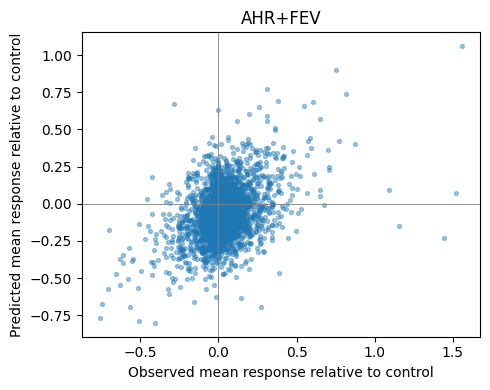

In [6]:
# Inspect the measured and predicted mean responses for one held-out condition.
from IPython.display import display
import matplotlib.pyplot as plt
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

condition = test_conditions[0]
canonical_labels = capra_data.adata.obs['perturbation'].astype(str)
control_mean = np.asarray(capra_data.adata[canonical_labels == 'control'].X.mean(axis=0)).ravel()
observed_mean = np.asarray(capra_data.adata[canonical_labels == condition].X.mean(axis=0)).ravel()
predicted_mean = predictions[condition].mean(axis=0)
response_table = pd.DataFrame({
    'observed_mean': observed_mean,
    'predicted_mean': predicted_mean,
    'observed_delta': observed_mean - control_mean,
    'predicted_delta': predicted_mean - control_mean,
}, index=capra_data.adata.var_names)
response_table.index.name = 'gene'
strongest = response_table['observed_delta'].abs().nlargest(10).index
print('Held-out condition:', condition)
display(response_table.loc[strongest].round(4))
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(response_table['observed_delta'], response_table['predicted_delta'], s=8, alpha=0.4)
ax.axhline(0, color='grey', linewidth=0.6)
ax.axvline(0, color='grey', linewidth=0.6)
ax.set(xlabel='Observed mean response relative to control',
       ylabel='Predicted mean response relative to control', title=condition)
fig.tight_layout()
plt.show()


## 5. Save predictions and run metadata


In [7]:
stage_started = time.perf_counter()
blocks = []
for condition, matrix in predictions.items():
    assert matrix.shape == (n_pred, capra_data.adata.n_vars)
    assert np.isfinite(matrix).all(), f'Non-finite prediction: {condition}'
    obs = pd.DataFrame(
        {'condition': condition, 'perturbation': condition, 'Expcategory': 'imputed'},
        index=[f'{condition}_pred_{i}' for i in range(len(matrix))],
    )
    blocks.append(ad.AnnData(
        X=matrix.astype(np.float32, copy=False), obs=obs,
        var=pd.DataFrame(index=capra_data.adata.var_names.copy()),
    ))
prediction_adata = ad.concat(blocks, merge='same')
assert prediction_adata.var_names.equals(capra_data.adata.var_names)
prediction_adata.uns['demo'] = {'name': demo_name, 'seed': seed}
output_dir.mkdir(parents=True, exist_ok=True)
prediction_path = output_dir / 'predictions.h5ad'
prediction_adata.write_h5ad(prediction_path)
timings['export_seconds'] = time.perf_counter() - stage_started
summary = {
    'demo': demo_name, 'seed': seed,
    'input_shape': list(capra_data.adata.shape),
    'split_conditions': {key: len(value) for key, value in capra_data.splits.items()},
    'predicted_conditions': list(predictions),
    'prediction_shape': list(prediction_adata.shape),
    'n_pred_per_condition': n_pred,
    'best_checkpoint': str(Path(model.fitted['metrics']['best_checkpoint']).relative_to(output_dir)),
    'epochs_completed': model.fitted['metrics']['epochs_completed'],
    'timings': timings,
    'total_seconds': time.perf_counter() - started,
    'environment': {
        'python': platform.python_version(), 'platform': platform.platform(),
        'torch': torch.__version__, 'numpy': np.__version__, 'pandas': pd.__version__,
        'device': model.fitted['metrics']['runtime']['device'],
        'torch_threads': torch.get_num_threads(),
    },
    'training': {
        'max_epochs': max_epochs, 'val_n_pred': val_n_pred,
        'num_workers': num_workers, 'batch_size': 192,
    },
}
(output_dir / 'summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved predictions:', prediction_path.relative_to(repo_root)
      if prediction_path.is_relative_to(repo_root) else prediction_path)
print('Prediction shape:', prediction_adata.shape)
print('Timings (seconds):', {k: round(v, 2) for k, v in timings.items()})
print('Total run seconds:', round(summary['total_seconds'], 2))


Saved predictions: demo/outputs/demo_norman_subset/predictions.h5ad
Prediction shape: (48, 5025)
Timings (seconds): {'data_preparation_seconds': 5.28, 'training_seconds': 8.07, 'prediction_seconds': 0.01, 'export_seconds': 0.04}
Total run seconds: 16.57


## 6. Reload the checkpoint and verify predictions


In [8]:
# Reload with the same data assets; no fitting occurs in this cell.
stage_started = time.perf_counter()
checkpoint = model.fitted['metrics']['best_checkpoint']
loaded = CAPRA(capra_data)
loaded.load_capra_response_operator(checkpoint, accelerator=accelerator, output_dir=output_dir / 'results')
first_condition = test_conditions[0]
reloaded = loaded.generate_counterfactual_profiles(
    pert_list=[first_condition], n_pred=n_pred, sampling_state=seed,
)[first_condition]
np.testing.assert_allclose(reloaded, predictions[first_condition], rtol=1e-5, atol=1e-5)
summary['checkpoint_reload_verified'] = True
summary['timings']['reload_seconds'] = time.perf_counter() - stage_started
summary['total_seconds'] = time.perf_counter() - started
(output_dir / 'summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Checkpoint reload verified:', first_condition)
print('Completed:', demo_name)
print('Prediction file:', prediction_path.relative_to(repo_root)
      if prediction_path.is_relative_to(repo_root) else prediction_path)
print('Verified prediction shape:', prediction_adata.shape)
print('End-to-end seconds:', round(summary['total_seconds'], 2))


Checkpoint reload verified: AHR+FEV
Completed: demo_norman_subset
Prediction file: demo/outputs/demo_norman_subset/predictions.h5ad
Verified prediction shape: (48, 5025)
End-to-end seconds: 17.16
